# VOLCANO PLOTS - PROTEOMICS

### Kod służy do generowania wykresów typu volcanoplot na podstawie danych pochodzących z analiz -omicznych.

Plik wejściowy w formacie .tsv powinien zawierac minimum kolumny z identyfikatorem porównania (Comparison (group1/group2)), zlogarytmowaną wartością ratio (AVG Log2 Ratio), zlogarytmowaną wartością q-value/FDR (-log qvalue) oraz nazwą genu ("Genes")

Wykorzystane biblioteki:
- numpy 2.2.4
- pandas 2.2.3
- matplotlib 3.10.0

Radosław Cacała, 23 lipca 2026

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

'''
1. Import danych z pliku .tsv i wstępna obróbka danych
'''

df = pd.read_csv(
    "LUHMES_lysates_ASTRAL_pure_ALL_candidates.tsv",
    sep="\t"
)

# W pliku wejściowym wartości AVG Log2 Ratio dla dwóch porównań sa odwrócone - trzeba przekształcić
df.loc[
    df["Comparison (group1/group2)"].isin(["CTRL / CLO", "RIS / CLO"]),
    "AVG Log2 Ratio"
] *= -1

# W kolumnie "Genes" interesuje nas tylko to, co jest do pierwszego średnika
df["Genes"] = df["Genes"].str.split(";").str[0]

'''
2. Przygotowanie wartości progowych dla białek różnicowych i dla białek z podpisami
'''
# Wartości progowe dla białek różnicowych są sztywne:
FC_THR = 0.263 # log2(1.2)
Q_THR = 1.301 #-log10(0.05)

# Wartości progowe dla białek z podpisami są zmienne i ustawiamy je
# w poniższym słowniku tak, żeby maksymalnie dużo białek 
# było opisanych, ale żeby podpisy nie pogarszały czytelności wykresu.
CFG = {
    "clo_ctrl": {
        "cmp": "CTRL / CLO",
        "fc_up": 1.25,
        "fc_dn": -1.30,
        "q_up": 7.05,
        "q_dn": 7.00,
    },
    "clo_ris": {
        "cmp": "RIS / CLO",
        "fc_up": 1.15,
        "fc_dn": -1.00,
        "q_up": 7.50,
        "q_dn": 6.25,
    },
    "ris_ctrl": {
        "cmp": "RIS / CTRL",
        "fc_up": 1.00,
        "fc_dn": -1.25,
        "q_up": 5.00,
        "q_dn": 5.00,
    },
}

In [8]:
'''
3. Aplikowanie wartości progowych do danych
'''
def make_masks(df, cmp, fc_up, fc_dn, q_up, q_dn):

    cmp_mask = df["Comparison (group1/group2)"] == cmp

    up = cmp_mask & (df["AVG Log2 Ratio"] >= FC_THR) & (df["-log qvalue"] >= Q_THR)
    dn = cmp_mask & (df["AVG Log2 Ratio"] <= -FC_THR) & (df["-log qvalue"] >= Q_THR)

    labels = {
        "up_fc": cmp_mask & (df["AVG Log2 Ratio"] >= fc_up) &
                 (df["-log qvalue"].between(Q_THR, q_up)),

        "up_q": cmp_mask & (df["AVG Log2 Ratio"] >= FC_THR) &
                (df["-log qvalue"] >= q_up),

        "dn_fc": cmp_mask & (df["AVG Log2 Ratio"] <= fc_dn) &
                 (df["-log qvalue"].between(Q_THR, q_dn)),

        "dn_q": cmp_mask & (df["AVG Log2 Ratio"] <= -FC_THR) &
                (df["-log qvalue"] >= q_dn),
    }

    return {
        "up": up,
        "dn": dn,
        "n_up": up.sum(),
        "n_dn": dn.sum(),
        "labels": labels,
    }

In [9]:
masks = {}

for k, v in CFG.items():
    masks[k] = make_masks(df, **v)

In [10]:
masks

{'clo_ctrl': {'up': 0         True
  1         True
  2        False
  3        False
  4        False
           ...  
  26922    False
  26923    False
  26924    False
  26925    False
  26926    False
  Length: 26927, dtype: bool,
  'dn': 0        False
  1        False
  2        False
  3         True
  4        False
           ...  
  26922    False
  26923    False
  26924    False
  26925    False
  26926    False
  Length: 26927, dtype: bool,
  'n_up': np.int64(312),
  'n_dn': np.int64(237),
  'labels': {'up_fc': 0        False
   1        False
   2        False
   3        False
   4        False
            ...  
   26922    False
   26923    False
   26924    False
   26925    False
   26926    False
   Length: 26927, dtype: bool,
   'up_q': 0         True
   1         True
   2        False
   3        False
   4        False
            ...  
   26922    False
   26923    False
   26924    False
   26925    False
   26926    False
   Length: 26927, dtype: bool,
   'dn_

In [11]:
'''
4. Funkcja do nanoszenia opisów na wykres
'''
def add_labels(ax, df_fc, df_q, x_edge,
               x_off=1.2,
               y_top=0.6,
               y_bottom=2):
    
    # złożenie dwóch podzbiorów danych i posortowanie względem q-value
    tmp = pd.concat([
        df_fc.assign(src="fc"),
        df_q.assign(src="q")
    ]).sort_values("-log qvalue")

    if tmp.empty:
        return

    # ustawnienie współrzędnych y dla kolejnych podpisów
    y0, y1 = ax.get_ylim()
    ys = np.linspace(y0 + y_bottom, y1 - y_top, len(tmp))

    #ustawnienie pozycji podpisów w osi x
    x_lab = x_edge - x_off if x_edge > 0 else x_edge + x_off

    # właściwe generowanie tekstu i linii na wykresie
    for (_, row), y_lab in zip(tmp.iterrows(), ys):

        ax.text(
            x_lab,
            y_lab,
            row["Genes"],
            fontsize=15,
            ha="left" if x_edge > 0 else "right"
        )

        ax.plot(
            [row["AVG Log2 Ratio"],
             x_lab],
            [row["-log qvalue"],
             y_lab],
            "--",
            lw=0.75,
            c="black"
        )

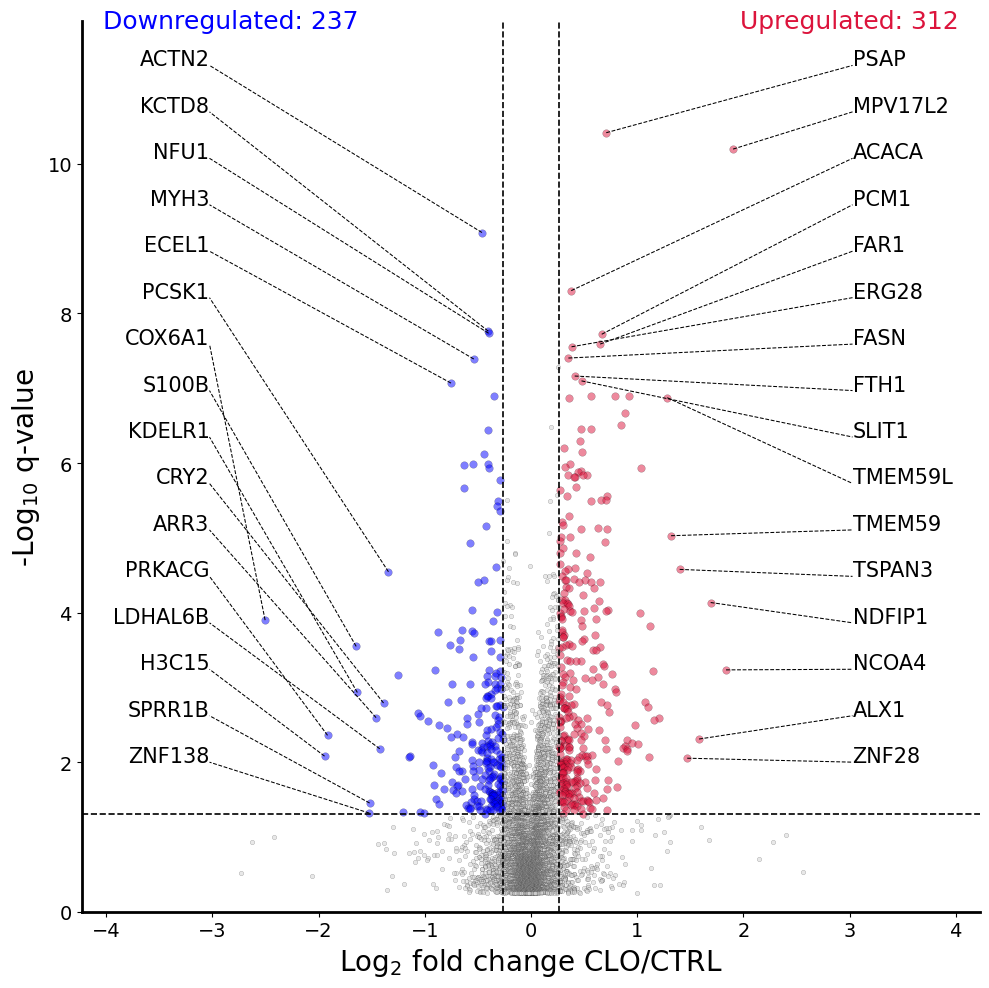

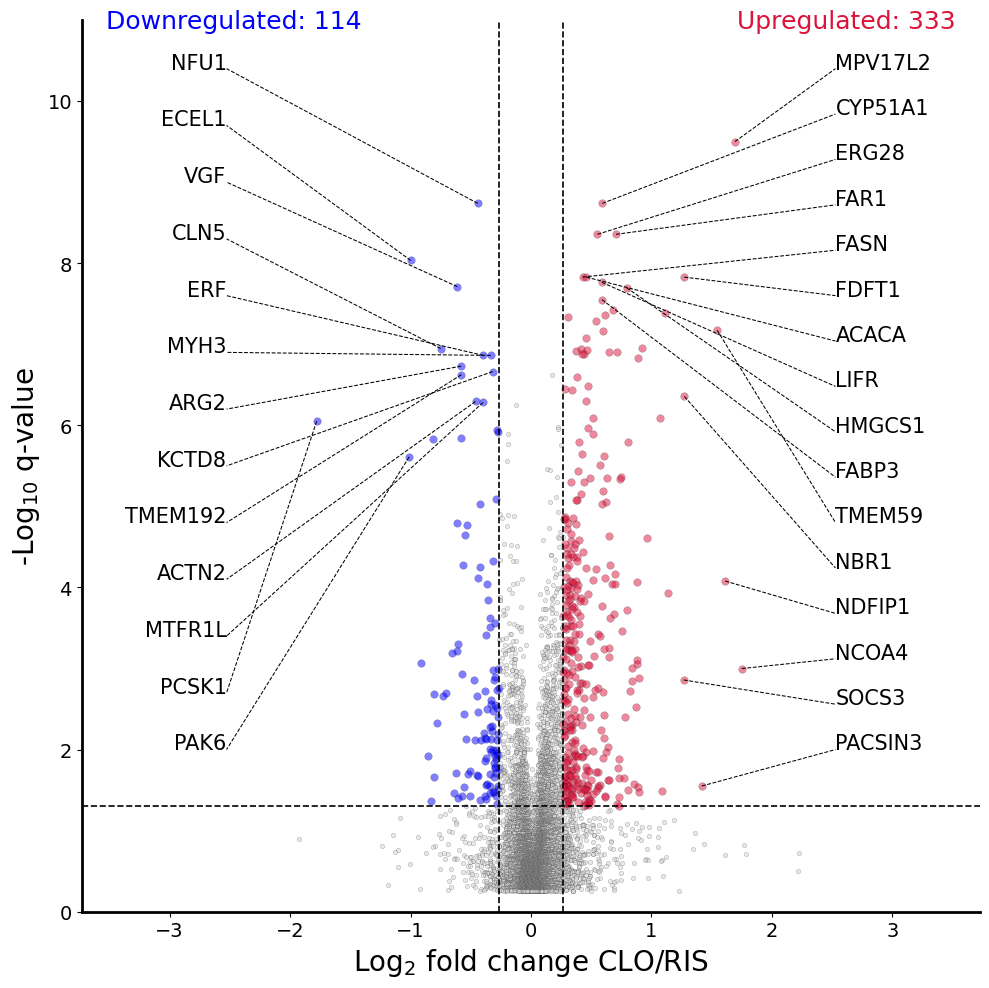

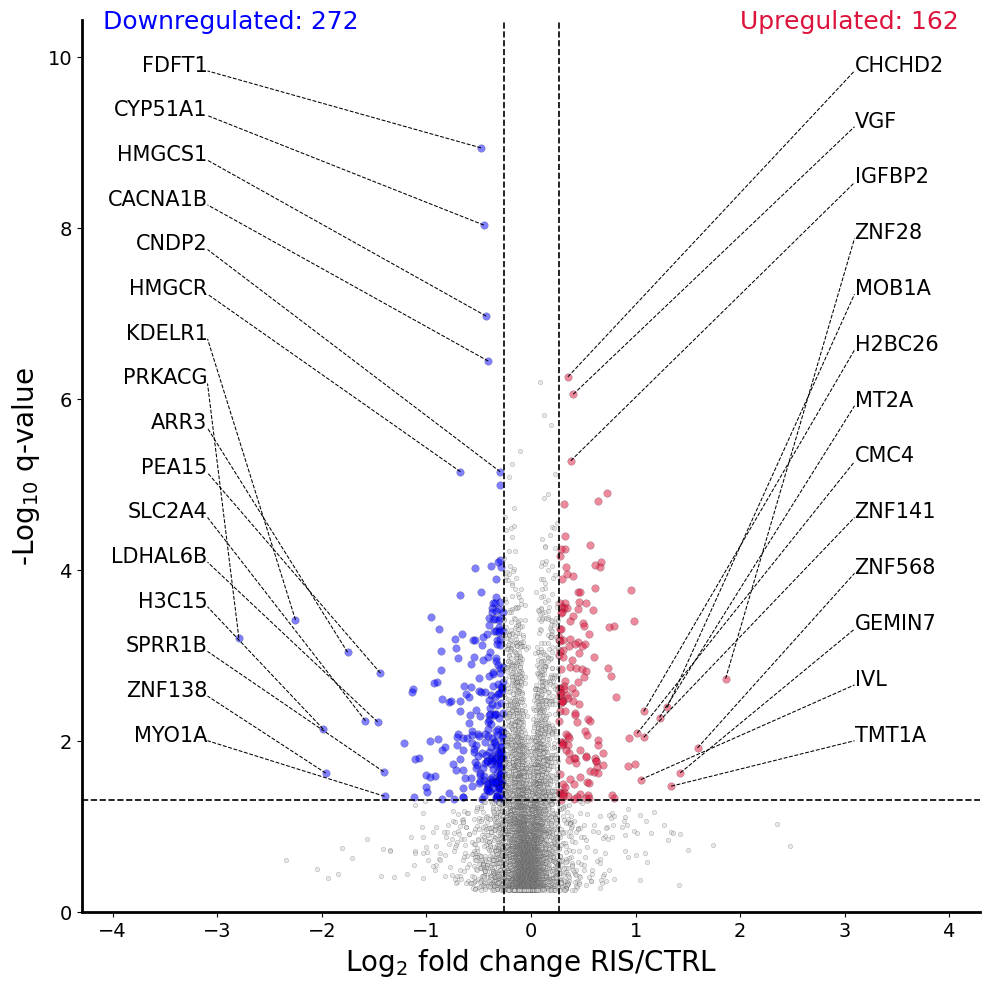

In [15]:
'''
5. Generowanie wykresów volcanoplot
'''
for name, cfg in CFG.items():

    cmp_name = cfg["cmp"] # pobiera nazwę porównania, która występuje w df

    sub = df[df["Comparison (group1/group2)"] == cmp_name].copy() #filtruje df pod kątem danego porównania
    m = masks[name] # maski dla danego porównania

    fig, ax = plt.subplots(figsize=(10, 10), dpi=100, facecolor="white") # przygotowanie obszaru wykresu

    # wartości do wykresu scatter
    x = sub["AVG Log2 Ratio"]
    y = sub["-log qvalue"]

    # dynamiczne przygotowanie długości osi zależne od rozmiaru danych
    ax.set_xlim(-abs(x).max() - 1.5, abs(x).max() + 1.5)
    ax.set_ylim(0, y.max() + 1.5)

    # przygotowanie wykresu scatterplot dla białek nieróżnicowych, downregulowanch i upregulowanych
    for mask, color, size in [
        (m["up"], "crimson", 30),
        (m["dn"], "blue", 30),
        (~(m["up"] | m["dn"]), "lightgray", 10),
    ]:
        ax.scatter(
            sub.loc[mask, "AVG Log2 Ratio"], #zmienna x
            sub.loc[mask, "-log qvalue"], #zmienna y
            s=size,
            c=color,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.5
        )
 
    # dodanie linii obrazujących próg FC i Q-value
    ax.axvline(FC_THR, linestyle="--", color="black", linewidth=1.2)
    ax.axvline(-FC_THR, linestyle="--", color="black", linewidth=1.2)
    ax.axhline(Q_THR, linestyle="--", color="black", linewidth=1.2)

    # przygotowanie etykiet (aplikacja funkcji add_labels)
    add_labels(
        ax,
        sub.loc[m["labels"]["up_fc"]],
        sub.loc[m["labels"]["up_q"]],
        x_edge=ax.get_xlim()[1],
    )

    add_labels(
        ax,
        sub.loc[m["labels"]["dn_fc"]],
        sub.loc[m["labels"]["dn_q"]],
        x_edge=ax.get_xlim()[0],
    )

    # dodanie liczników białek różnicowych nad danymi
    ax.text(
        ax.get_xlim()[0] + 0.2,
        ax.get_ylim()[1] - 0.1,
        f"Downregulated: {m['n_dn']}",
        color="blue",
        fontsize=18,
        ha="left"
    )

    ax.text(
        ax.get_xlim()[1] - 0.2,
        ax.get_ylim()[1] - 0.1,
        f"Upregulated: {m['n_up']}",
        color="crimson",
        fontsize=18,
        ha="right"
    )

    # dodanie opisów osi
    ax.set_xlabel(
        f"Log$_{{2}}$ fold change {name.upper().replace('_','/')}",
        fontsize=20
    )
    ax.set_ylabel("-Log$_{10}$ q-value", fontsize=20)

    # dodanie znaczników na osiach
    ax.tick_params(axis="both", labelsize=14)

    # formatowanie osi
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)

    ax.grid(False)
    plt.tight_layout()

    # zapisanie wykresu do formatu .svg
    plt.savefig(f"volcanoplot_{name}.svg", format="svg", dpi=300)
    plt.show()
